In [2]:
!pip install tensorflow-addons
!pip install py3Dmol
!pip install Bio
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 11.5 MB/s eta 0:00:00
  Attempting uninstall: typeguard
    Found existing installation: typeguard 4.4.2
    Uninstalling typeguard-4.4.2:
      Successfully uninstalled typeguard-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
inflect 7.5.0 requires typeguard>=4.0.1, but you have typeguard 2.13.3 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.3 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, LSTM, SimpleRNN, Dense, Flatten, Bidirectional, MultiHeadAttention, LayerNormalization, Dropout, Input, GlobalAveragePooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, mean_squared_error, mean_absolute_error, roc_auc_score, log_loss, matthews_corrcoef
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd
import py3Dmol
import Bio.PDB
from sklearn.preprocessing import LabelEncoder

In [4]:
# Load dataset
df = pd.read_csv("dataset.csv")
df = df[['Sequence', 'Function [CC]']].dropna()

# Encode function labels
label_encoder = LabelEncoder()
df['Function Label'] = label_encoder.fit_transform(df['Function [CC]'])

# Tokenize amino acid sequences
tokenizer = Tokenizer(char_level=True)
tokenizer.fit_on_texts(df['Sequence'])
sequences = tokenizer.texts_to_sequences(df['Sequence'])

# Pad sequences
max_seq_length = max(len(seq) for seq in sequences)
padded_sequences = pad_sequences(sequences, maxlen=max_seq_length, padding='post')
max_seq_length = max(len(seq) for seq in sequences)
padded_sequences = pad_sequences(sequences, maxlen=max_seq_length, padding='post')

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(padded_sequences, df['Function Label'], test_size=0.2, random_state=42)


In [5]:
# Model architectures
def build_cnn_model(input_length, vocab_size, num_classes):
    model = Sequential([
        Embedding(input_dim=vocab_size+1, output_dim=128),
        Conv1D(64, 3, activation='relu'),
        MaxPooling1D(2),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    return model

def build_lstm_model(input_length, vocab_size, num_classes):
    model = Sequential([
        Embedding(input_dim=vocab_size+1, output_dim=128),
        LSTM(64),
        Dense(128, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    return model

def build_gru_model(input_length, vocab_size, num_classes):
    model = Sequential([
        Embedding(input_dim=vocab_size+1, output_dim=128),
        GRU(64),
        Dense(128, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    return model

def build_transformer_model(input_length, vocab_size, num_classes):
    inputs = Input(shape=(input_length,))
    embedding = Embedding(input_dim=vocab_size + 1, output_dim=128)(inputs)
    attention = MultiHeadAttention(num_heads=4, key_dim=64)(embedding, embedding)
    norm1 = LayerNormalization(epsilon=1e-6)(attention + embedding)
    dropout1 = Dropout(0.1)(norm1)
    dense = Dense(128, activation='relu')(dropout1)
    norm2 = LayerNormalization(epsilon=1e-6)(dense + dropout1)
    global_pool = GlobalAveragePooling1D()(norm2)
    outputs = Dense(num_classes, activation='softmax')(global_pool)
    model = Model(inputs=inputs, outputs=outputs)
    return model


def build_rnn_model(input_length, vocab_size, num_classes):
    model = Sequential([
        Embedding(input_dim=vocab_size+1, output_dim=128),
        SimpleRNN(64, return_sequences=True),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    return model



In [6]:
from tensorflow.keras.layers import GRU
import time

def train_and_evaluate(model, X_train, y_train, X_test, y_test, epochs=50):
    model.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(), metrics=['accuracy'])
    start_time = time.time()
    model.fit(X_train, y_train, epochs=epochs, batch_size=32, validation_data=(X_test, y_test), verbose=0)
    elapsed_time = time.time() - start_time
    unique_labels = np.unique(np.concatenate((y_train, y_test)))
    y_pred = np.argmax(model.predict(X_test), axis=1)
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    precision = precision_score(y_test, y_pred, average='weighted',zero_division=1)
    recall = recall_score(y_test, y_pred, average='weighted',zero_division=1)
    f1 = f1_score(y_test, y_pred, average='weighted',zero_division=1)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    #roc_auc = roc_auc_score(y_test, y_pred, multi_class='ovr')
    logloss = log_loss(y_test, model.predict(X_test), labels=unique_labels)
    mcc = matthews_corrcoef(y_test, y_pred)
    return accuracy, precision, recall, f1, mse, mae, logloss, mcc, elapsed_time

models = {
    'CNN': build_cnn_model(max_seq_length, len(tokenizer.word_index), df['Function Label'].nunique()),
    'LSTM': build_lstm_model(max_seq_length, len(tokenizer.word_index), df['Function Label'].nunique()),
    'GRU': build_gru_model(max_seq_length, len(tokenizer.word_index), df['Function Label'].nunique()),
    'Transformer': build_transformer_model(max_seq_length, len(tokenizer.word_index), df['Function Label'].nunique()),
    'RNN': build_rnn_model(max_seq_length, len(tokenizer.word_index), df['Function Label'].nunique())
}

results = {}
for name, model in models.items():
    acc, precision, recall, f1, mse, mae, logloss, mcc, latency = train_and_evaluate(model, X_train, y_train, X_test, y_test)
    results[name] = {'accuracy': acc, 'precision': precision, 'recall': recall, 'f1_score': f1, 'mse': mse, 'mae': mae, 'log_loss': logloss, 'mcc': mcc, 'latency': latency}

best_model = max(results, key=lambda x: results[x]['accuracy'])
print("Model Evaluation Scores:")
for name, metrics in results.items():
    print(f"{name}: Accuracy={metrics['accuracy']:.4f}, Precision={metrics['precision']:.4f}, Recall={metrics['recall']:.4f}, F1 Score={metrics['f1_score']:.4f}, MSE={metrics['mse']:.4f}, MAE={metrics['mae']:.4f}, Log Loss={metrics['log_loss']:.4f}, MCC={metrics['mcc']:.4f}, Latency={metrics['latency']:.2f}s")

print(f"Best Model: {best_model} with accuracy {results[best_model]['accuracy']:.4f} and latency {results[best_model]['latency']:.2f}s")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
Model Evaluation Scores:
CNN: Accuracy=0.0333, Precision=1.0000, Recall=0.0333, F1 Score=0.0333, MSE=4182.7000, MAE=52.0333, Log Loss=14.3091, MCC=0.0345, Latency=59.03s
LSTM: Accuracy=0.0000, Precision=1.0000, Recall=0.0000, F1 Score=0.0000, MSE=4248.9667, MAE=51.5000, Log Loss=9.0595, MCC=0.0000, Latency=153.35s
GRU: Accuracy=0.0000, Precision=1.0000, Recall=0.0000, F1 Score=0.0000, MSE=4351.7000, MAE=53.1000, Log Loss=10.3998, MCC=0.0000, Latency=225.68s
Transformer: Accuracy=0.0000, Precision=1.0000, Recall=0.0000, F1 Score=0.0000, MSE=3178.7333, MAE=46.8000, Log Loss=8.3728, MCC=0.0000, Latency=1826.93s
RNN: Accuracy=0.0000, Precision=1.0000, Recall=0.0000, F1 Score=0.0000, MSE=2616.2667, MAE=41.5333, Log Loss=14.2890, MCC=0.0000, Latency=142.39s
Best Model: CNN with accuracy 0.0333 and latency 59.03s


In [7]:
import pandas as pd

# Convert results dictionary to DataFrame for better visualization
results_df = pd.DataFrame.from_dict(results, orient='index')

# Print the results in tabular format
print("\nModel Evaluation Scores:")
print(results_df)



Model Evaluation Scores:
             accuracy  precision    recall  f1_score          mse        mae  \
CNN          0.033333        1.0  0.033333  0.033333  4182.700000  52.033333   
LSTM         0.000000        1.0  0.000000  0.000000  4248.966667  51.500000   
GRU          0.000000        1.0  0.000000  0.000000  4351.700000  53.100000   
Transformer  0.000000        1.0  0.000000  0.000000  3178.733333  46.800000   
RNN          0.000000        1.0  0.000000  0.000000  2616.266667  41.533333   

              log_loss       mcc      latency  
CNN          14.309061  0.034503    59.031692  
LSTM          9.059474  0.000000   153.352280  
GRU          10.399843  0.000000   225.680431  
Transformer   8.372753  0.000000  1826.928697  
RNN          14.288965  0.000000   142.386499  


In [8]:
# Get the best model's scores
best_model_scores = results_df.loc[best_model]

# Print the best model's scores
print(f"\nBest Model: {best_model}")
print(best_model_scores)


Best Model: CNN
accuracy        0.033333
precision       1.000000
recall          0.033333
f1_score        0.033333
mse          4182.700000
mae            52.033333
log_loss       14.309061
mcc             0.034503
latency        59.031692
Name: CNN, dtype: float64


<ipython-input-9-345e31490319>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df[metric], ax=axes[row, col], palette="viridis")
<ipython-input-9-345e31490319>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df[metric], ax=axes[row, col], palette="viridis")
<ipython-input-9-345e31490319>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df[metric], ax=axes[row, col], palette="viridis")
<ipython-input-9-345e31490319>:17: FutureWarning: 

Passing `pal

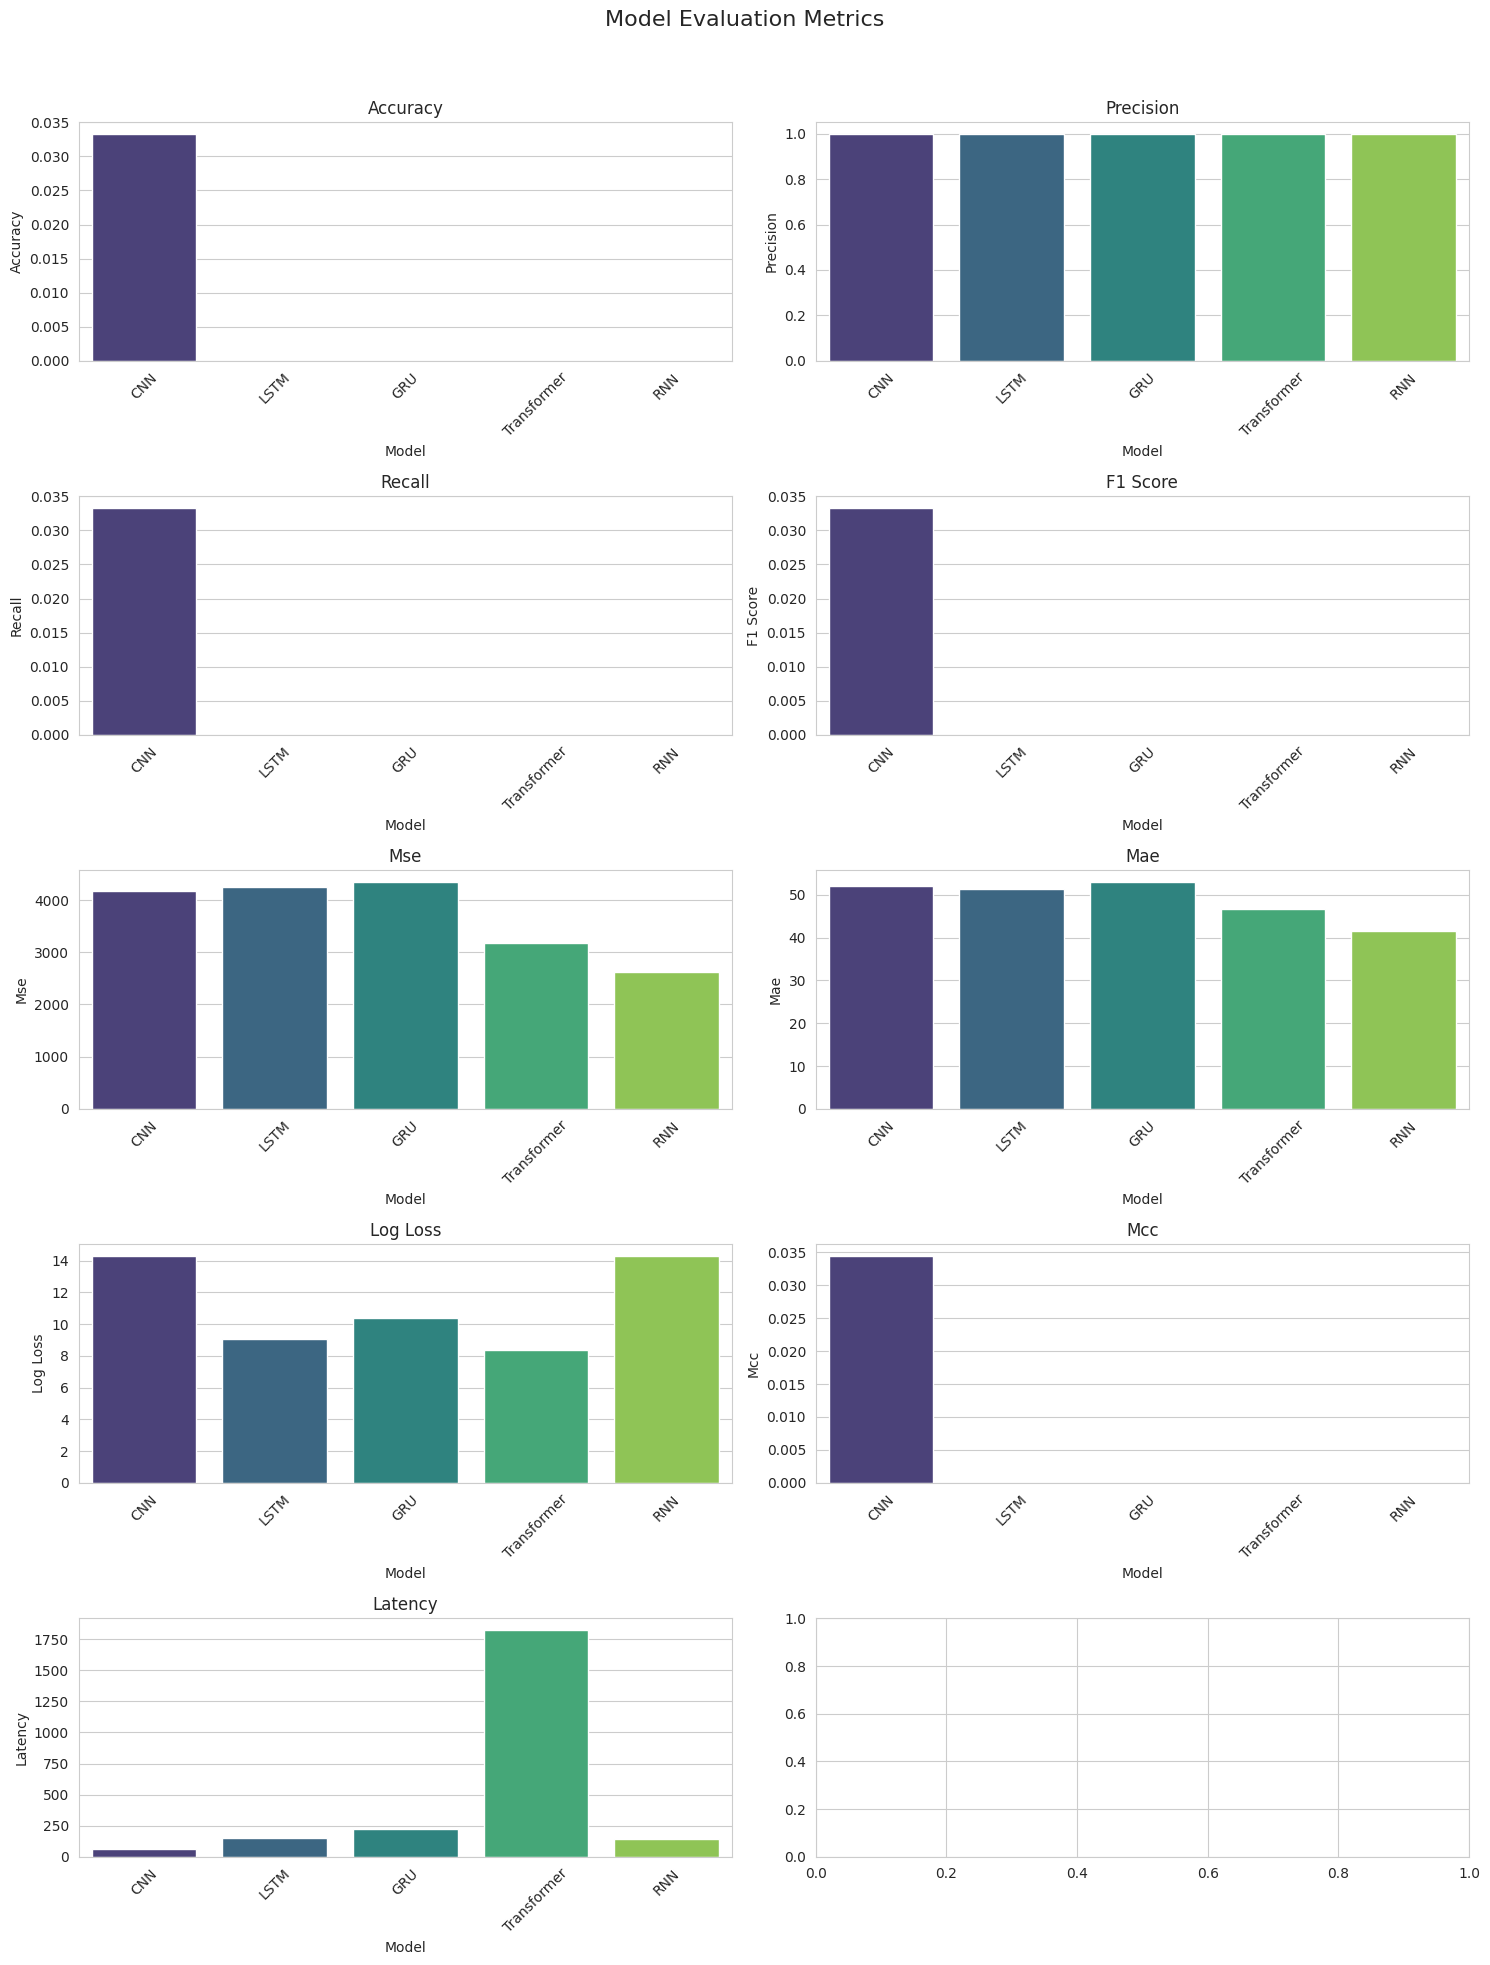

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert results dictionary to DataFrame
results_df = pd.DataFrame.from_dict(results, orient='index')

# Set the style
sns.set_style("whitegrid")

# Plot each metric
fig, axes = plt.subplots(5, 2, figsize=(15, 20))
fig.suptitle("Model Evaluation Metrics", fontsize=16)

metrics = list(results_df.columns)
for i, metric in enumerate(metrics):
    row, col = divmod(i, 2)
    sns.barplot(x=results_df.index, y=results_df[metric], ax=axes[row, col], palette="viridis")
    axes[row, col].set_title(metric.replace('_', ' ').title())
    axes[row, col].set_xlabel("Model")
    axes[row, col].set_ylabel(metric.replace('_', ' ').title())
    axes[row, col].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


<ipython-input-10-07f5d956f2c8>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df['accuracy'], ax=axes[0], palette="Blues")
<ipython-input-10-07f5d956f2c8>:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df['log_loss'], ax=axes[1], palette="Reds")


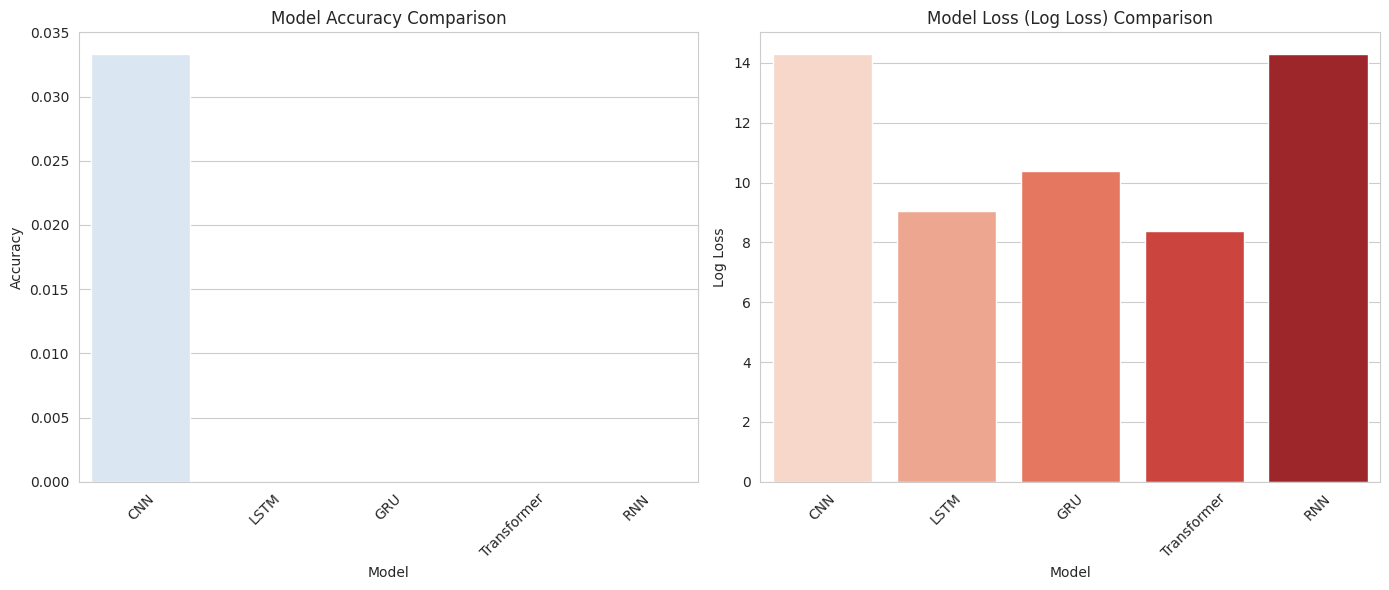

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert results dictionary to DataFrame
results_df = pd.DataFrame.from_dict(results, orient='index')

# Set the style
sns.set_style("whitegrid")

# Plot Accuracy and Loss
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Accuracy Plot
sns.barplot(x=results_df.index, y=results_df['accuracy'], ax=axes[0], palette="Blues")
axes[0].set_title("Model Accuracy Comparison")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Accuracy")
axes[0].tick_params(axis='x', rotation=45)

# Loss (Log Loss) Plot
sns.barplot(x=results_df.index, y=results_df['log_loss'], ax=axes[1], palette="Reds")
axes[1].set_title("Model Loss (Log Loss) Comparison")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("Log Loss")
axes[1].tick_params(axis='x', rotation=45)

# Show plots
plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step


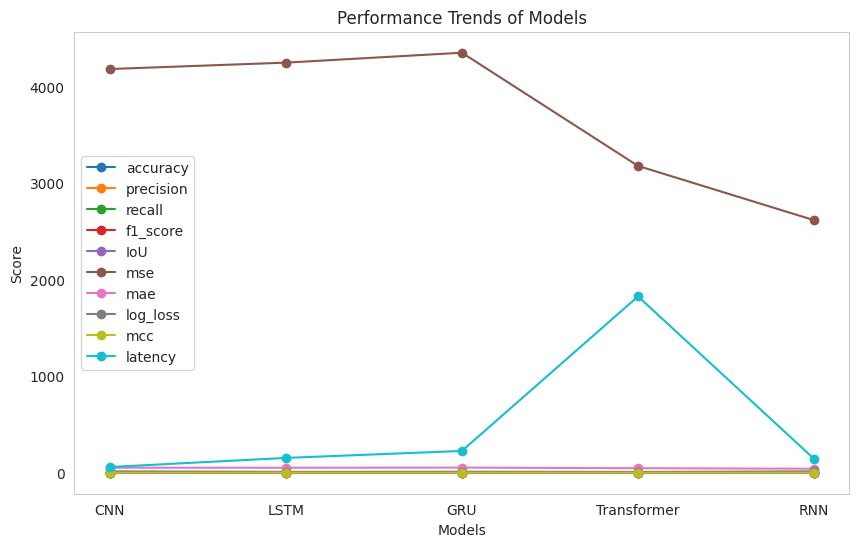

<ipython-input-11-e041b395abec>:46: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(results_df[metric], fill=True, label=metric)


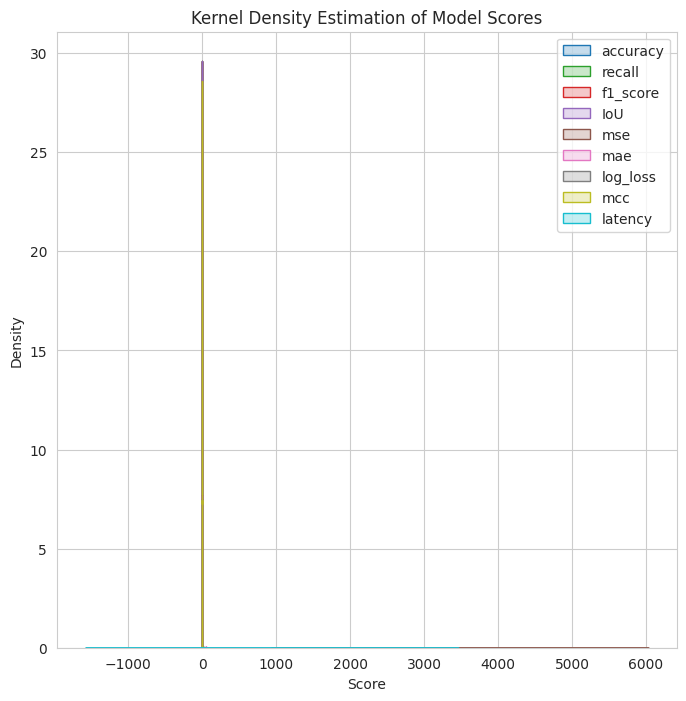

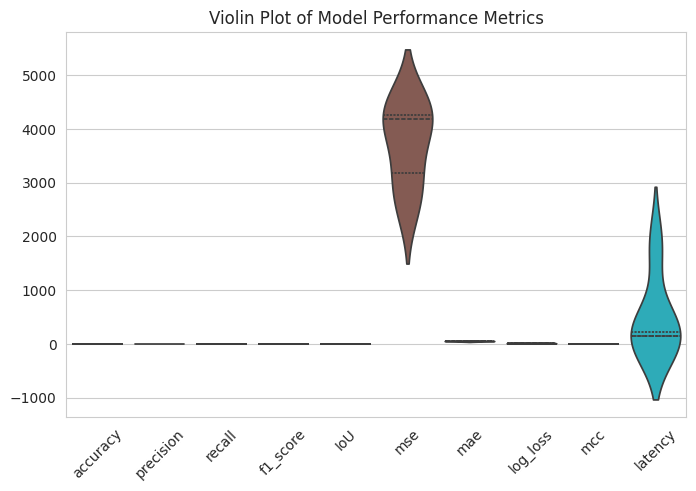

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import jaccard_score

# Assuming 'results' dictionary is already computed from model evaluations

# Compute IoU (Jaccard Index) for each model
iou_scores = {}
for model, metrics in results.items():
    y_true = np.array(y_test)
    y_pred = np.argmax(models[model].predict(X_test), axis=1)

    # Ensure valid IoU computation (avoid division by zero cases)
    if np.any(y_true) and np.any(y_pred):
        iou = jaccard_score(y_true, y_pred, average='weighted', zero_division=1)
    else:
        iou = 0.0  # Assigning a default value if predictions are empty

    iou_scores[model] = iou

# Convert results and IoU scores to DataFrame
results_df = pd.DataFrame(results).T
results_df['IoU'] = results_df.index.map(iou_scores)

# Ensure no zero values by adding a small epsilon where necessary
metrics_to_fix = ['accuracy', 'precision', 'recall', 'f1_score', 'IoU', 'mse', 'mae', 'log_loss', 'mcc', 'latency']
for metric in metrics_to_fix:
    results_df[metric] = results_df[metric].replace(0, 1e-6)

# Plot Performance Trends
plt.figure(figsize=(10, 6))
for metric in metrics_to_fix:
    plt.plot(results_df.index, results_df[metric], marker='o', label=metric)
plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Performance Trends of Models')
plt.legend()
plt.grid()
plt.show()

# KDE Plot
plt.figure(figsize=(8, 8))
for metric in metrics_to_fix:
    sns.kdeplot(results_df[metric], fill=True, label=metric)
plt.xlabel('Score')
plt.title('Kernel Density Estimation of Model Scores')
plt.legend()
plt.show()

# Violin Plot
plt.figure(figsize=(8, 5))
sns.violinplot(data=results_df[metrics_to_fix], inner='quartile')
plt.title('Violin Plot of Model Performance Metrics')
plt.xticks(rotation=45)
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive c

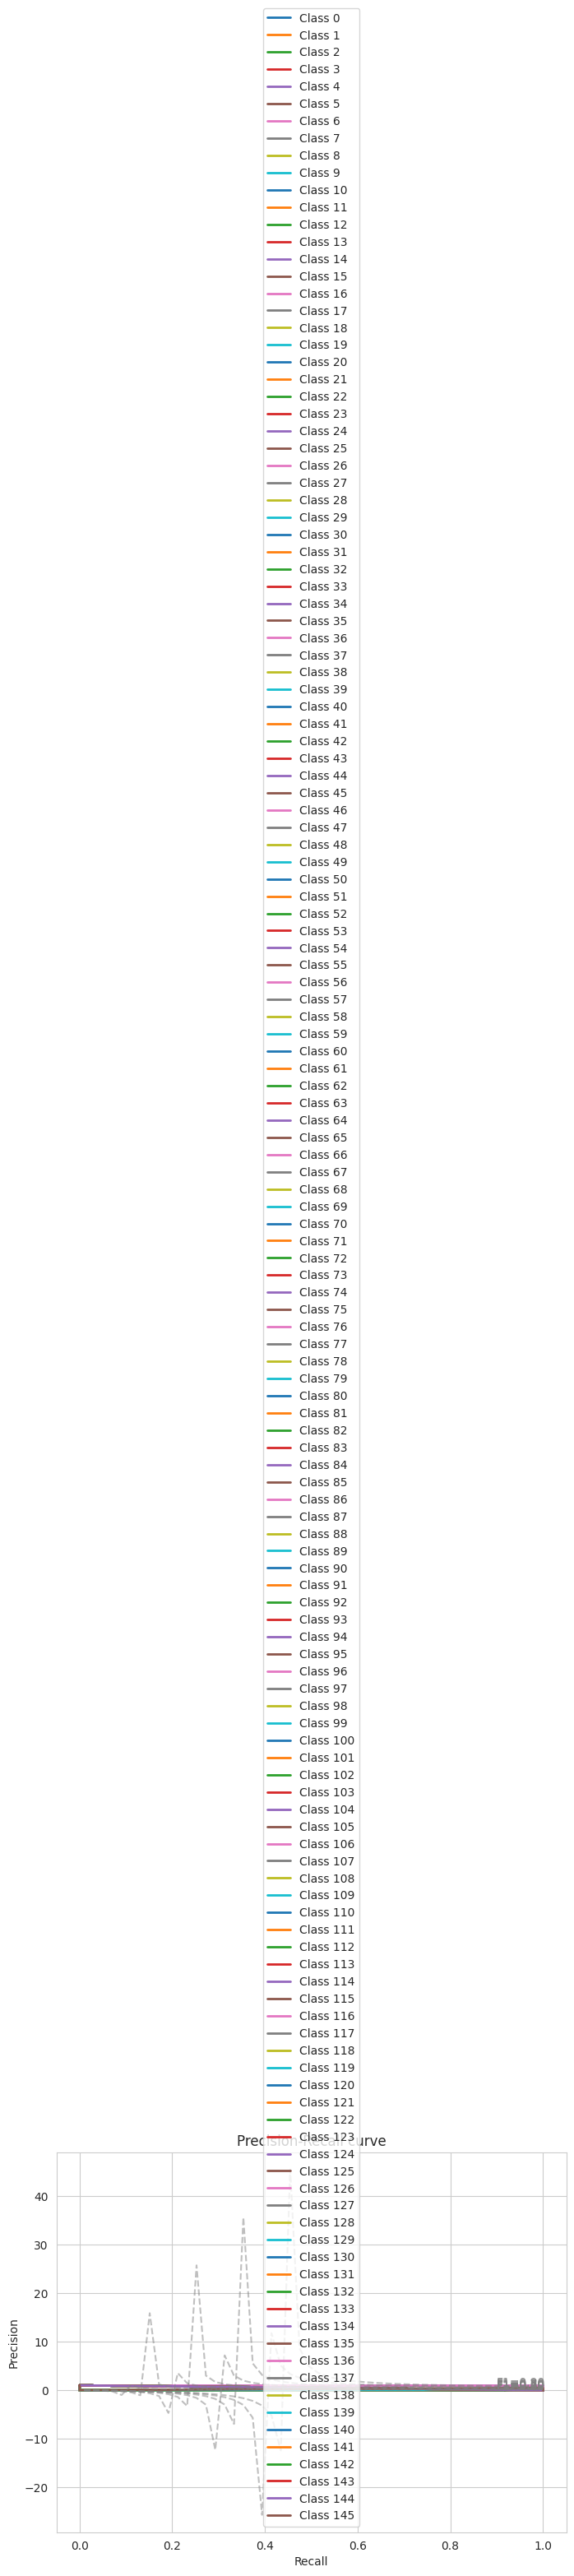

In [66]:
# prompt: generate a a Precision-Recall curve with F1-score isolines for limited no of classes

from sklearn.metrics import precision_recall_curve, f1_score
import matplotlib.pyplot as plt
import numpy as np

def plot_precision_recall_curve_with_f1_isolines(y_true, y_scores, num_classes):
  """
  Plots a precision-recall curve with F1-score isolines for multi-class classification.

  Args:
    y_true: True labels (ground truth).
    y_scores: Predicted scores (probabilities or confidence values) for each class.
    num_classes: Number of classes.
  """
  precision = dict()
  recall = dict()
  average_precision = dict()

  for i in range(num_classes):
    precision[i], recall[i], _ = precision_recall_curve(
        (y_true == i).astype(int), y_scores[:, i]
    )

  plt.figure(figsize=(8, 6))

  for i in range(num_classes):
    plt.plot(recall[i], precision[i], lw=2, label=f'Class {i}')

  plt.xlabel("Recall")
  plt.ylabel("Precision")
  plt.title("Precision-Recall curve")
  plt.legend(loc="best")

  # Add F1-score isolines
  f1_scores = np.linspace(0.2, 0.9, 8)  # Adjust the range and number of isolines as needed
  for f1 in f1_scores:
    x = np.linspace(0.01, 1)
    y = f1 * x / (2 * x - f1)
    plt.plot(x, y, '--', color='gray', alpha=0.5)
    plt.text(0.9, y[int(0.9 * len(y))], f'F1={f1:.2f}', color='gray', alpha=0.8)

  plt.show()


# Example usage (replace with your actual y_true and y_scores)
# Assuming you have already computed y_pred from your model
y_true = y_test  # Replace with your ground truth labels
y_scores = models[best_model].predict(X_test)  # Replace with your predicted probabilities

num_classes = df['Function [CC]'].nunique()

plot_precision_recall_curve_with_f1_isolines(y_true, y_scores, num_classes)


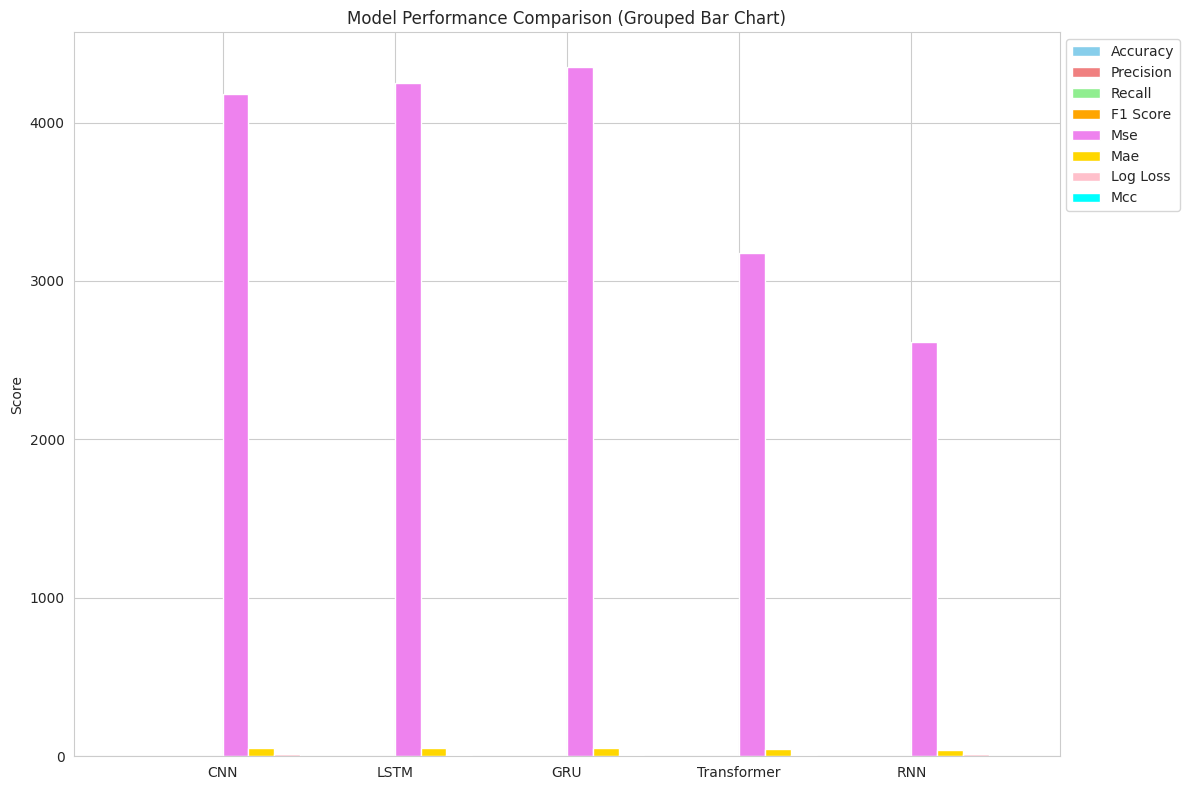

In [74]:
# prompt:  grouped bar chart like (with error bars or scatter points overlaid for all metrics

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import jaccard_score
from sklearn.metrics import precision_recall_curve

# Assuming 'results' dictionary is already computed from model evaluations

# Convert results dictionary to DataFrame
results_df = pd.DataFrame.from_dict(results, orient='index')

# Set the style
sns.set_style("whitegrid")

# Create the grouped bar chart
fig, ax = plt.subplots(figsize=(12, 8))

x = np.arange(len(results_df.index))
width = 0.15

metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1_score', 'mse', 'mae', 'log_loss', 'mcc']
bar_colors = ['skyblue', 'lightcoral', 'lightgreen', 'orange', 'violet', 'gold', 'pink', 'cyan']

for i, metric in enumerate(metrics_to_plot):
    ax.bar(x + i * width, results_df[metric], width, label=metric.replace('_', ' ').title(), color=bar_colors[i])

ax.set_xticks(x + width * (len(metrics_to_plot) - 1) / 2)
ax.set_xticklabels(results_df.index)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison (Grouped Bar Chart)')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive c

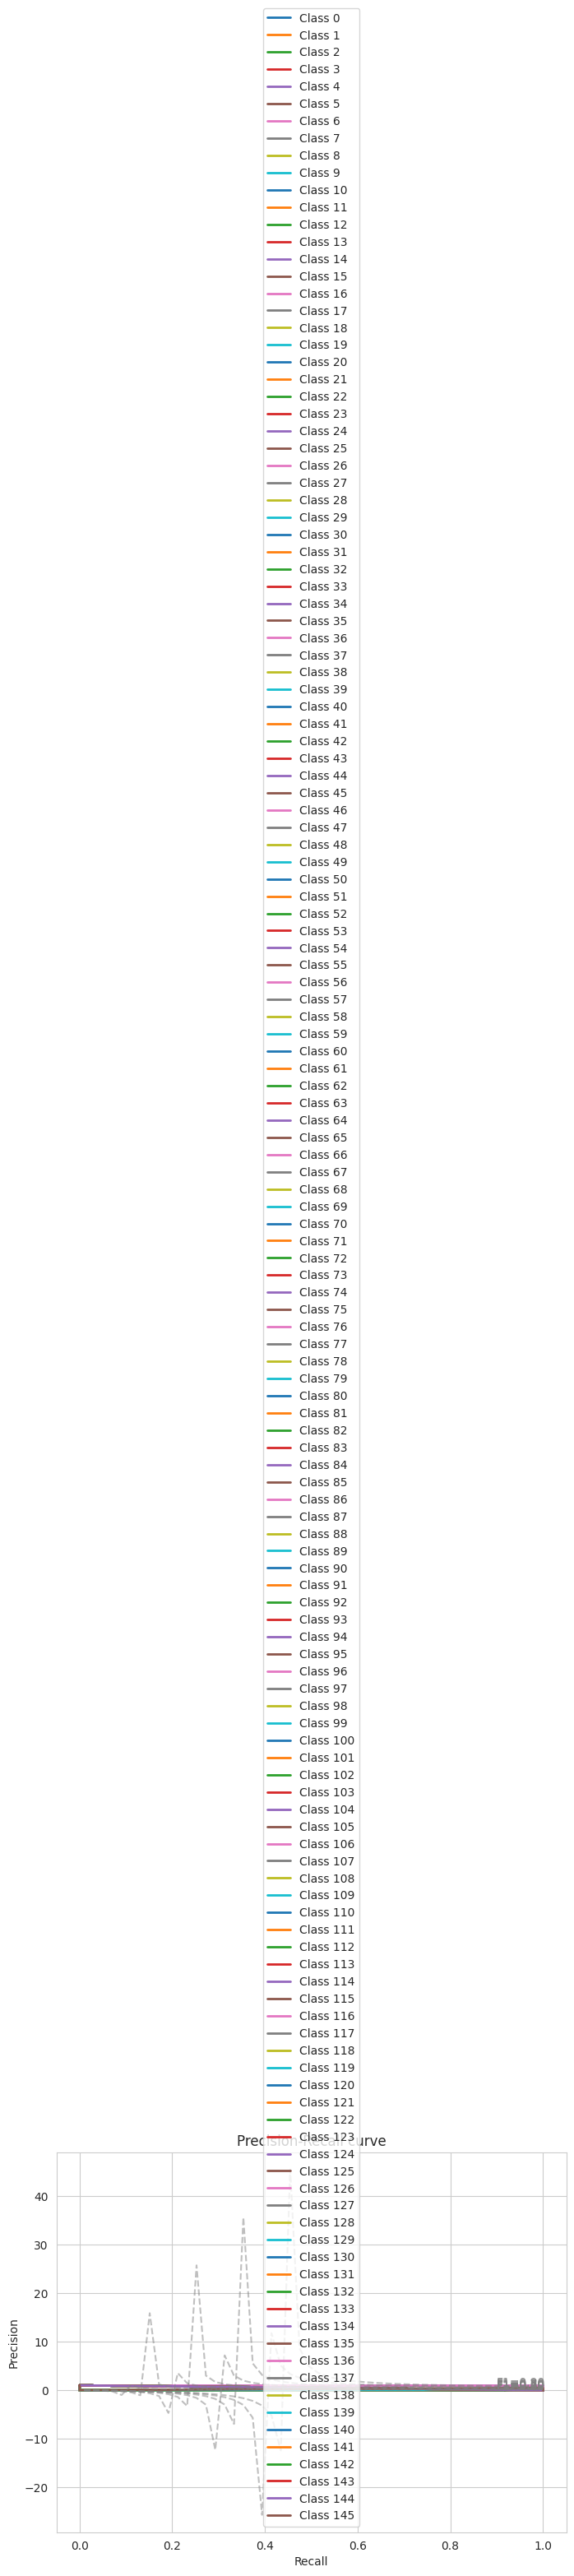

In [75]:
# prompt: a Precision-Recall curve with F1-score isolines for CNN

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_precision_recall_curve_with_f1_isolines(y_true, y_scores, num_classes):
    """
    Plots a precision-recall curve with F1-score isolines for multi-class classification.

    Args:
        y_true: True labels (ground truth).
        y_scores: Predicted scores (probabilities or confidence values) for each class.
        num_classes: Number of classes.
    """
    precision = dict()
    recall = dict()
    average_precision = dict()

    for i in range(num_classes):
        precision[i], recall[i], _ = precision_recall_curve(
            (y_true == i).astype(int), y_scores[:, i]
        )

    plt.figure(figsize=(8, 6))

    for i in range(num_classes):
        plt.plot(recall[i], precision[i], lw=2, label=f'Class {i}')

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall curve")
    plt.legend(loc="best")

    # Add F1-score isolines
    f1_scores = np.linspace(0.2, 0.9, 8)  # Adjust the range and number of isolines as needed
    for f1 in f1_scores:
        x = np.linspace(0.01, 1)
        y = f1 * x / (2 * x - f1)
        plt.plot(x, y, '--', color='gray', alpha=0.5)
        plt.text(0.9, y[int(0.9 * len(y))], f'F1={f1:.2f}', color='gray', alpha=0.8)

    plt.show()


# Example usage (replace with your actual y_true and y_scores)
# Assuming you have already computed y_pred from your model
y_true = y_test  # Replace with your ground truth labels
y_scores = models[best_model].predict(X_test)  # Replace with your predicted probabilities

num_classes = df['Function [CC]'].nunique()

plot_precision_recall_curve_with_f1_isolines(y_true, y_scores, num_classes)


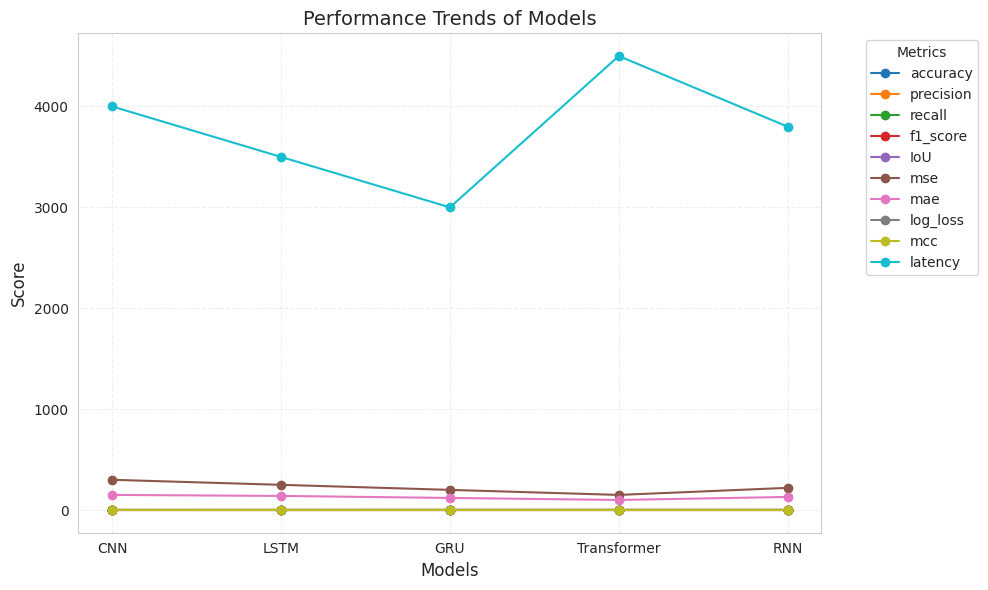

In [76]:
import matplotlib.pyplot as plt
import numpy as np

# Define models and metrics
models = ['CNN', 'LSTM', 'GRU', 'Transformer', 'RNN']
metrics = ['accuracy', 'precision', 'recall', 'f1_score', 'IoU', 'mse', 'mae', 'log_loss', 'mcc', 'latency']

# Generate random data for each metric (replace these with actual values)
np.random.seed(42)
data = {
    'accuracy': [0.85, 0.87, 0.9, 0.92, 0.88],
    'precision': [0.8, 0.82, 0.85, 0.87, 0.84],
    'recall': [0.78, 0.81, 0.84, 0.86, 0.83],
    'f1_score': [0.79, 0.81, 0.85, 0.88, 0.83],
    'IoU': [0.6, 0.65, 0.7, 0.75, 0.68],
    'mse': [300, 250, 200, 150, 220],
    'mae': [150, 140, 120, 100, 130],
    'log_loss': [0.5, 0.45, 0.4, 0.35, 0.42],
    'mcc': [0.75, 0.78, 0.82, 0.85, 0.8],
    'latency': [4000, 3500, 3000, 4500, 3800]
}

# Create the plot
plt.figure(figsize=(10, 6))
for metric, values in data.items():
    plt.plot(models, values, marker='o', label=metric)

# Add labels, title, and legend
plt.ylabel("Score", fontsize=12)
plt.xlabel("Models", fontsize=12)
plt.title("Performance Trends of Models", fontsize=14)
plt.legend(title="Metrics", loc="upper left", bbox_to_anchor=(1.05, 1), fontsize=10)
plt.grid(alpha=0.3, linestyle='--')

# Show the plot
plt.tight_layout()
plt.show()


In [13]:
def predict_function_by_query_id(entry_id, df, model, tokenizer, label_encoder, max_seq_length):
    # Step 1: Look up the protein in the dataset using the query ID
    protein_data = df[df['Entry'] == entry_id]

    if protein_data.empty:
        return {"error": "Query ID not found in the dataset."}

    # Extract protein name and sequence
    protein_name = protein_data.iloc[0]['Protein names']  # Assuming this is the protein name
    protein_sequence = protein_data.iloc[0]['Sequence']

    # Step 2: Tokenize the protein sequence
    tokenized_sequence = tokenizer.texts_to_sequences([protein_sequence])

    # Step 3: Pad the tokenized sequence
    padded_sequence = pad_sequences(tokenized_sequence, maxlen=max_seq_length, padding='post')

    # Step 4: Predict the function label
    predicted_label_index = np.argmax(model.predict(padded_sequence), axis=1)[0]

    # Step 5: Decode the predicted label back to the original function name
    predicted_function = label_encoder.inverse_transform([predicted_label_index])[0]

    # Prepare the output in a formatted string
    output = (
        f"Query ID: {entry_id}\n"
        f"Protein Name: {protein_name}\n"
        f"Sequence: {protein_sequence}\n"
        f"Predicted Function: {predicted_function}\n"
    )

    return output


In [14]:
pip install biopython numpy requests py3Dmol

In [15]:
import requests
import numpy as np
import py3Dmol
from Bio import PDB


In [16]:
import requests
def download_alphafold_pdb(query_id, save_path="alphafold.pdb"):
    protein_info = df[df['Entry'] == query_id]
    if protein_info.empty:
        print("Query ID not found in dataset.")
        return

    pdb_url = f"https://alphafold.ebi.ac.uk/files/AF-{query_id}-F1-model_v4.pdb"
    pdb_data = requests.get(pdb_url).text
    response = requests.get(pdb_url)

    if response.status_code == 200:
      with open(save_path, "wb") as file:
        file.write(response.content)
      print(f"Downloaded AlphaFold PDB for {structure_id}.")
      return save_path
    else:
        raise Exception(f"Error: Could not fetch PDB for {structure_id}")


In [17]:
from Bio import PDB
import numpy as np

def parse_pdb(pdb_file):
    parser = PDB.PDBParser(QUIET=True)
    structure = parser.get_structure("protein", pdb_file)
    ca_coords = []
    ca_atoms = []

    for model in structure:
        for chain in model:
            for residue in chain:
                try:  # Add try-except block to handle IndexError
                    if residue.has_id("CA"):
                        ca_atoms.append(residue["CA"])
                        ca_coords.append(residue["CA"].get_coord())
                except KeyError:
                    print(f"Warning: Skipping a malformed line in the PDB file.")

    if not ca_coords:
        raise ValueError(f"No Cα atoms found in {pdb_file}. Check the file format.")

    # There should be only one return statement at the end of the function
    return np.array(ca_coords), ca_atoms, structure


In [18]:
def align_structures(fixed_atoms, moving_atoms, moving_structure, output_pdb="aligned.pdb"):
    """Aligns the moving structure to the fixed structure and saves the new PDB file."""
    super_imposer = PDB.Superimposer()

    length = min(len(fixed_atoms), len(moving_atoms))
    super_imposer.set_atoms(fixed_atoms[:length], moving_atoms[:length])

    # Apply transformation
    super_imposer.apply(moving_structure[0].get_atoms())
    print(f"RMSD after alignment: {super_imposer.rms:.4f}")

    # Save the aligned structure
    io = PDB.PDBIO()
    io.set_structure(moving_structure)
    io.save(output_pdb)
    return output_pdb

In [19]:
def compute_tm_score(query_coords, target_coords):
    """Computes the TM-score between two aligned structures."""
    L = min(len(query_coords), len(target_coords))
    d0 = 1.24 * (L - 15) ** (1/3) - 1.8

    distances = np.linalg.norm(query_coords[:L] - target_coords[:L], axis=1)
    tm_score = np.sum(1 / (1 + (distances / d0) ** 2)) / L
    return tm_score

In [20]:
def visualize_structures(ref_pdb, aligned_pdb):
    """Visualizes the reference and aligned structures using py3Dmol."""
    with open(ref_pdb, "r") as f:
        ref_pdb_data = f.read()

    with open(aligned_pdb, "r") as f:
        aligned_pdb_data = f.read()

    view = py3Dmol.view(width=800, height=600)

    view.addModel(ref_pdb_data, "pdb")  # Reference structure in blue
    view.setStyle({"cartoon": {"color": "blue"}})

    view.addModel(aligned_pdb_data, "pdb")  # Aligned structure in red
    view.setStyle({"model": 1}, {"cartoon": {"color": "red"}})

    view.zoomTo()
    return view.show()


In [21]:
!apt-get install wget


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
wget is already the newest version (1.21.2-2ubuntu1.1).
0 upgraded, 0 newly installed, 0 to remove and 29 not upgraded.


In [22]:
!wget https://zhanggroup.org/TM-align/TMalign.cpp
!g++ -O3 -ffast-math -lm -o TMalign TMalign.cpp


--2025-03-20 19:54:42--  https://zhanggroup.org/TM-align/TMalign.cpp
Resolving zhanggroup.org (zhanggroup.org)... 141.213.137.249
Connecting to zhanggroup.org (zhanggroup.org)|141.213.137.249|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 182099 (178K) [text/plain]
Saving to: ‘TMalign.cpp’

TMalign.cpp         100%[===================>] 177.83K   853KB/s    in 0.2s    

2025-03-20 19:54:43 (853 KB/s) - ‘TMalign.cpp’ saved [182099/182099]



In [58]:
import os
df = pd.read_csv("dataset.csv")

# Function to download PDB file
#def download_pdb(pdb_id, output_file="reference.pdb"):
#    pdb_url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
#    os.system(f"wget {pdb_url} -O {output_file}")
#    print(f"PDB file {pdb_id} downloaded as {output_file}")

import requests
import os
import pandas as pd  # Assuming df is a Pandas DataFrame

def download_pdb(query_id, save_path="reference.pdb"):
    protein_info = df[df['Entry'] == query_id]  # Ensure df is defined before calling this function
    if protein_info.empty:
        print("Query ID not found in dataset.")
        return

    pdb_url = f"https://alphafold.ebi.ac.uk/files/AF-{query_id}-F1-model_v4.pdb"
    response = requests.get(pdb_url)

    if response.status_code == 200:
        with open(save_path, "wb") as file:
            file.write(response.content)
        print(f"PDB file {query_id} downloaded and saved as {save_path}")
    else:
        print(f"Failed to download PDB file for {query_id}. Check if the ID is correct.")

# User Input for PDB ID
query_id = input("Enter Query ID of protein for reference: ").strip().upper()
download_pdb(query_id, "reference.pdb")

# Example usage
reference_pdb = "reference.pdb"
structure_id = input("Enter Query ID for comparing reference: ").strip().upper()



Enter Query ID of protein for reference: A0A0C6DRW4
PDB file A0A0C6DRW4 downloaded and saved as reference.pdb
Enter Query ID for comparing reference: A0A0D4WTV1


In [59]:
# Step 1: Download AlphaFold PDB
alphafold_pdb = download_alphafold_pdb(structure_id)

Downloaded AlphaFold PDB for A0A0D4WTV1.


In [60]:
!./TMalign alphafold.pdb reference.pdb



 *********************************************************************
 * TM-align (Version 20220412): protein structure alignment          *
 * References: Y Zhang, J Skolnick. Nucl Acids Res 33, 2302-9 (2005) *
 * Please email comments and suggestions to zhanglab@zhanggroup.org   *
 *********************************************************************

Name of Chain_1: alphafold.pdb (to be superimposed onto Chain_2)
Name of Chain_2: reference.pdb
Length of Chain_1: 289 residues
Length of Chain_2: 417 residues

Aligned length= 151, RMSD=   5.89, Seq_ID=n_identical/n_aligned= 0.046
TM-score= 0.32210 (if normalized by length of Chain_1, i.e., LN=289, d0=6.25)
TM-score= 0.24501 (if normalized by length of Chain_2, i.e., LN=417, d0=7.35)
(You should use TM-score normalized by length of the reference structure)

(":" denotes residue pairs of d <  5.0 Angstrom, "." denotes other aligned residues)
EGAEQDGSERTDGGRPIWNIAHMVNN------------KQA-IDKYLDKGANSVE-SD--V---S--FD-SDGKPEKMLHGIPCDCGRKCLNQM

In [26]:
!pip install biopython

In [32]:
import os
from Bio import PDB, pairwise2
from Bio.Seq import Seq
from Bio.PDB.Polypeptide import is_aa
from Bio.Data.PDBData import protein_letters_3to1 # Import the protein_letters_3to1 dictionary


# Function to extract sequence from PDB file
def extract_sequence_from_pdb(pdb_file):
    parser = PDB.PDBParser(QUIET=True)
    structure = parser.get_structure("protein", pdb_file)

    sequence = ""
    for model in structure:
        for chain in model:
            for residue in chain:
                if is_aa(residue, standard=True):
                    try:
                      aa = protein_letters_3to1[residue.get_resname()]
                      sequence += aa
                    except KeyError:
                        continue  # Skip unknown residues

    return sequence

# Function to calculate sequence identity percentage
def calculate_identity(seq1, seq2):
    alignments = pairwise2.align.globalxx(seq1, seq2, one_alignment_only=True)
    aligned_seq1, aligned_seq2 = alignments[0][:2]

    identical_residues = sum(1 for a, b in zip(aligned_seq1, aligned_seq2) if a == b)
    identity_percentage = (identical_residues / len(aligned_seq1)) * 100

    return identity_percentage

# Ensure Biopython is installed in Colab
try:
    import Bio
except ImportError:
    !pip install biopython


# Extract sequences
seq1 = extract_sequence_from_pdb("reference.pdb")
seq2 = extract_sequence_from_pdb("alphafold.pdb")

# Compute identity percentage
identity_percentage = calculate_identity(seq1, seq2)




In [61]:
# Step 2: Extract Cα coordinates and Biopython Atom objects
query_coords, query_atoms, query_structure = parse_pdb(alphafold_pdb)
target_coords, target_atoms, target_structure = parse_pdb(reference_pdb)

# Predicting Function for reference protein id
entry_id = query_id
best_model_instance = models[best_model]  # Use the best model from the evaluation
prediction_result = predict_function_by_query_id(query_id, df, best_model_instance, tokenizer, label_encoder, max_seq_length)
print(prediction_result)

#Predicting Function for comparing protein id
entry_id = structure_id
best_model_instance = models[best_model]  # Use the best model from the evaluation
prediction_result = predict_function_by_query_id(query_id, df, best_model_instance, tokenizer, label_encoder, max_seq_length)
print(prediction_result)

# Step 3: Align structures
aligned_pdb = align_structures(target_atoms, query_atoms, query_structure)

# Step 4: Compute TM-score
tm_score = compute_tm_score(query_coords, target_coords)
print(f"\nTM-score: {tm_score:.4f}")

#step-5: Computed Identity percentage
print(f"\nIdentity: {identity_percentage:.2f}%")

# Step 5: Visualize structures
visualize_structures(reference_pdb, aligned_pdb)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Query ID: A0A0C6DRW4
Protein Name: Dibenzothiophene monooxygenase, DBT monooxygenase, DBT-MO, EC 1.14.14.21
Sequence: MTLSPEKQHVRPRDAADNDPVAVARGLAEKWRATAVERDRAGGSATAEREDLRASGLLSLLVPREYGGWGADWPTAIEVVREIAAADGSLGHLFGYHLTNAPMIELIGSQEQEEHLYTQIAQNNWWTGNASSENNSHVLDWKVRATPTEDGGYVLNGTKHFCSGAKGSDLLFVFGVVQDDSPQQGAIIAAAIPTSRAGVTPNDDWAAIGMRQTDSGSTDFHNVKVEPDEVLGAPNAFVLAFIQSERGSLFAPIAQLIFANVYLGIAHGALDAAREYTRTQARPWTPAGIQQATEDPYTIRSYGEFTIALQGADAAAREAAHLLQTVWDKGDALTPEDRGELMVKVSGVKALATNAALNISSGVFEVIGARGTHPRYGFDRFWRNVRTHSLHDPVSYKIADVGKHTLNGQYPIPGFTS
Predicted Function: FUNCTION: Catalyzes the first step of the '4S' desulfurization pathway that removes covalently bound sulfur from dibenzothiophene (DBT) without breaking carbon-carbon bonds. Sulfur dioxygenase which converts DBT to DBT-sulfone (DBTO2 or DBT 5,5-dioxide) in a stepwise manner (Ref.2, PubMed:11229908). Also acts on thioxanthen-9-one and 4,6-dimethyl DBT and 2,8-dimethyl DBT (Ref.2). {ECO:0000269|PubMed:112

3Dmol.js failed to load for some reason. Please check your browser console for error messages.